<a href="https://colab.research.google.com/github/shafiqa-nabila/PCVK_Ganjil2026/blob/main/Week5_22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# ===== SEL IDENTITAS JANGAN DIHAPUS, HARUS SEL PERTAMA =====
import datetime
import hashlib
import platform
import sys
import zoneinfo

NAMA = 'Shafiqa Nabila Maharani Khoirunnisa'
NIM = '244107020221'  # <-- Ganti dengan NIM Anda

N = int(NIM[-3:])

# Perhitungan Parameter Sesuai Rumus Rumus Jobsheet (Dihitung Otomatis)
PARAM = {
    'bins': 2 ** ((N % 4) + 3),
    'clip': round(1.0 + (N % 5) * 0.5, 1),
    'tile': (N % 4) + 2,
    'L': 2 ** ((N % 3) + 1),
}

waktu = datetime.datetime.now(zoneinfo.ZoneInfo('Asia/Jakarta'))

print('NAMA   :', NAMA)
print('NIM    :', NIM, 'N:', N)
for k, v in PARAM.items():
  print(f'PARAM {k:<5}: {v}')
print('WAKTU  :', waktu.strftime('%Y-%m-%d %H:%M:%S %Z'))
print('SISTEM :', sys.version.split()[0], platform.platform())
kunci = NIM + ' ' + waktu.strftime('%Y-%m-%d')
print('TOKEN  :', hashlib.sha256(kunci.encode()).hexdigest()[:16])

NAMA   : Shafiqa Nabila Maharani Khoirunnisa
NIM    : 244107020221 N: 221
PARAM bins : 16
PARAM clip : 1.5
PARAM tile : 3
PARAM L    : 8
WAKTU  : 2026-10-01 09:18:43 WIB
SISTEM : 3.13.15 Linux-6.6.122+-x86_64-with-glibc2.39
TOKEN  : 56319204cdfe5065


E-1 PERCOBAAN HISTOGRAM

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np
import math
import os
import glob

In [8]:
import os
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

# Path folder sesuai yang Anda gunakan
CONTOH = '/content/drive/MyDrive/PCVK 2026/Images'
img_path = os.path.join(CONTOH, 'Lenna.png')  # Gunakan 'lena.jpg' (satu huruf n)

# 1. Baca gambar
img_lena = cv.imread(img_path)

if img_lena is None:
  raise FileNotFoundError(
      f"Berkas tidak ditemukan pada '{img_path}'. Pastikan nama berkas 'lena.jpg' dan Google Drive sudah ter-mount."
  )

# 2. Konversi BGR ke RGB
img_rgb = cv.cvtColor(img_lena, cv.COLOR_BGR2RGB)

height, width, depth = img_rgb.shape
red = [0] * 256
green = [0] * 256
blue = [0] * 256

for y in range(height):
  for x in range(width):
    red[img_rgb[y, x, 0]] += 1
    green[img_rgb[y, x, 1]] += 1
    blue[img_rgb[y, x, 2]] += 1

names = np.arange(256)
fig, axs = plt.subplots(1, 3, figsize=(15, 4), sharex=True, sharey=True)
fig.suptitle(NIM + ' - Histogram RGB plot')
fig.text(0.06, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.01, 'Intensitas Warna', ha='center')

axs[0].bar(names, red, color='red')
axs[1].bar(names, green, color='green')
axs[2].bar(names, blue, color='blue')
plt.show()

FileNotFoundError: Berkas tidak ditemukan pada '/content/drive/MyDrive/PCVK 2026/Images/Lenna.png'. Pastikan nama berkas 'lena.jpg' dan Google Drive sudah ter-mount.

PERTANYAAN PRAKTIKUM E1

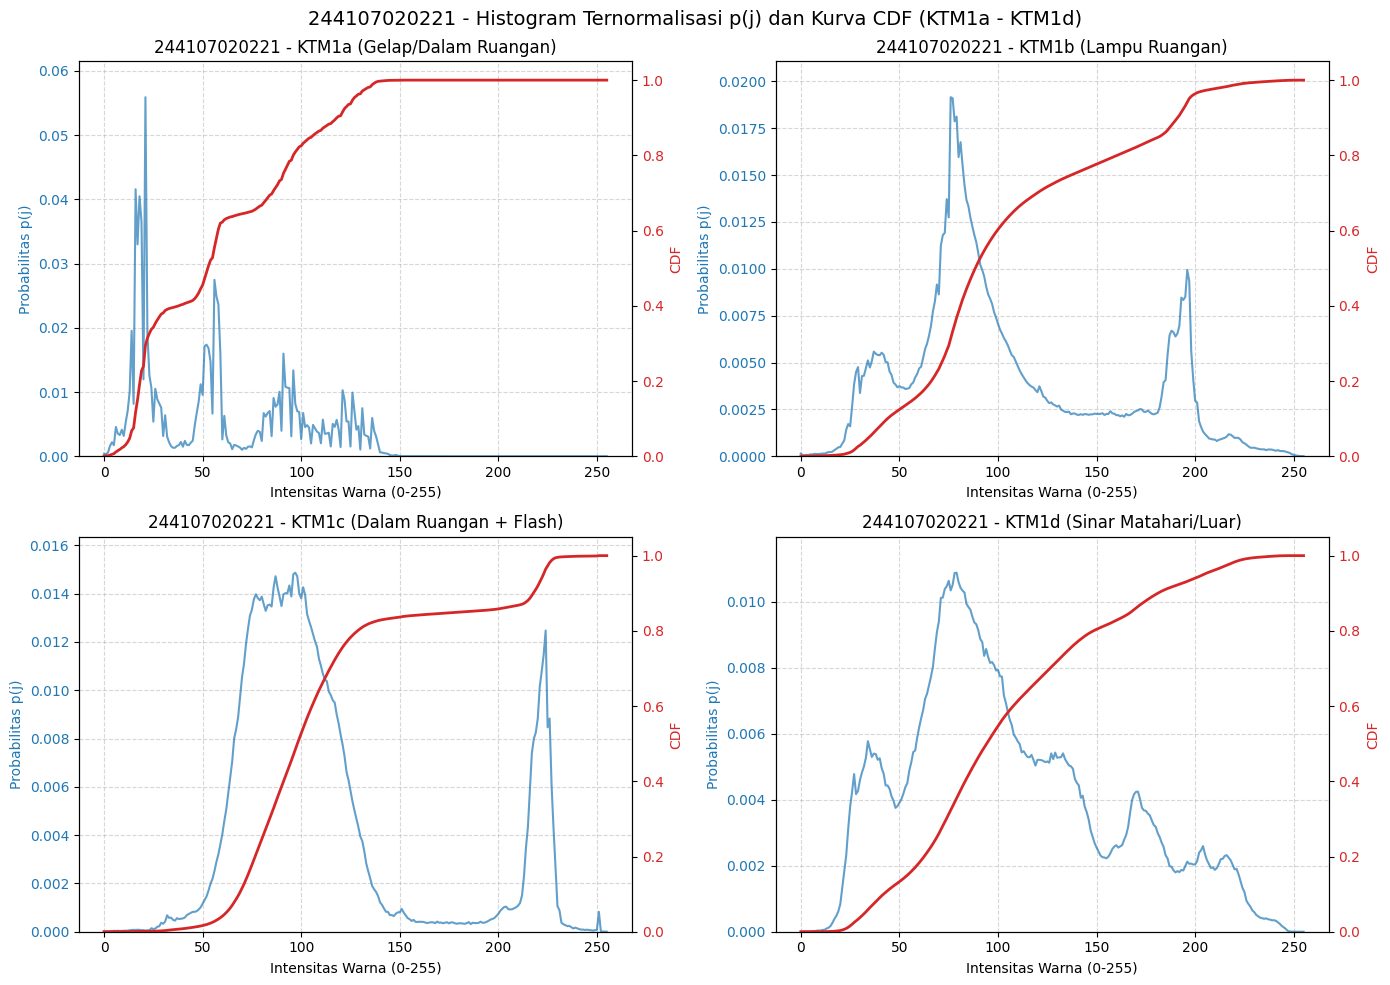

In [10]:
import os
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

# 1. Pastikan NIM Anda sudah diisi
NIM = '244107020221'  # <-- Ganti dengan NIM Anda

# Path direktori penyimpanan citra KTM Anda
BASE = '/content/drive/MyDrive/PCVK 2026/Images/' + NIM

# Daftar nama file dan kondisi pencahayaannya
ktm_files = [
    ('KTM1a.jpg', 'KTM1a (Gelap/Dalam Ruangan)'),
    ('KTM1b.jpg', 'KTM1b (Lampu Ruangan)'),
    ('KTM1c.jpg', 'KTM1c (Dalam Ruangan + Flash)'),
    ('KTM1d.jpg', 'KTM1d (Sinar Matahari/Luar)'),
]

# Plot 2x2
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    f'{NIM} - Histogram Ternormalisasi p(j) dan Kurva CDF (KTM1a - KTM1d)',
    fontsize=14,
)

for i, (fname, title) in enumerate(ktm_files):
  row, col = divmod(i, 2)
  img_path = os.path.join(BASE, fname)

  if os.path.exists(img_path):
    # Baca citra grayscale
    gray = cv.imread(img_path, cv.IMREAD_GRAYSCALE)

    # Hitung histogram, p(j) ternormalisasi, dan CDF
    h, _ = np.histogram(gray.ravel(), bins=256, range=[0, 256])
    p = h / gray.size  # Probabilitas p(j)
    cdf = np.cumsum(p)  # CDF (Cumulative Distribution Function)

    ax1 = axs[row, col]

    # Sumbu Y Kiri: Probabilitas p(j) (Batang/Line Biru)
    color1 = 'tab:blue'
    ax1.set_xlabel('Intensitas Warna (0-255)')
    ax1.set_ylabel('Probabilitas p(j)', color=color1)
    ax1.plot(p, color=color1, alpha=0.7, label='p(j) Normalisasi')
    ax1.tick_params(axis='y', labelcolor=color1)
    ax1.set_ylim(0, max(p) * 1.1)

    # Sumbu Y Kanan: CDF (Garis Merah)
    ax2 = ax1.twinx()
    color2 = 'tab:red'
    ax2.set_ylabel('CDF', color=color2)
    ax2.plot(cdf, color=color2, linewidth=2, label='CDF')
    ax2.tick_params(axis='y', labelcolor=color2)
    ax2.set_ylim(0, 1.05)

    ax1.set_title(f'{NIM} - {title}')
    ax1.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

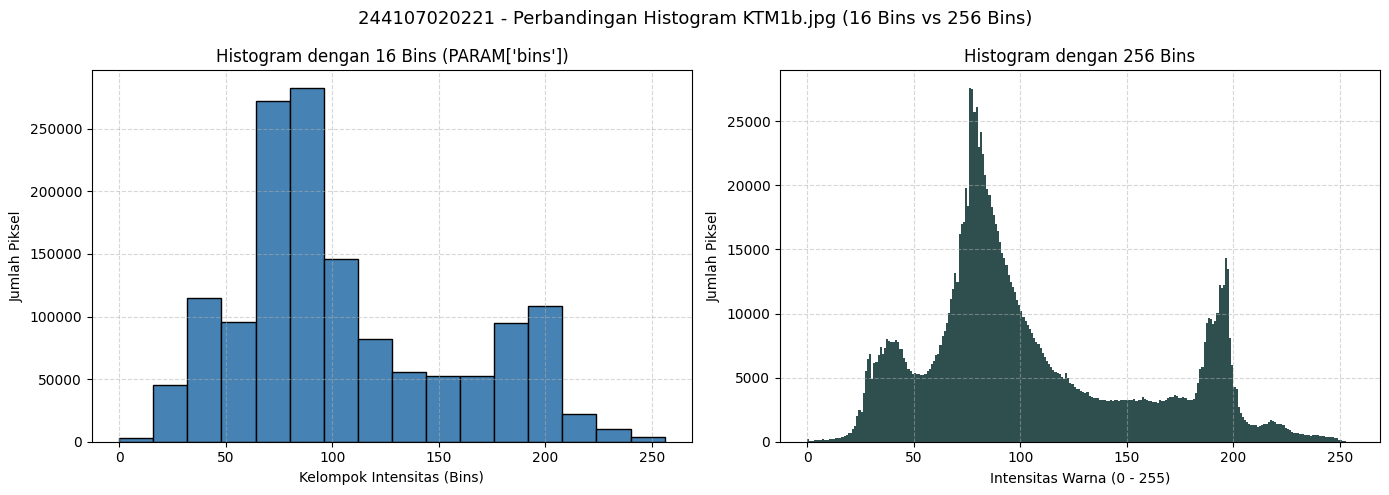

In [12]:
import os
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

# Pastikan NIM Anda sudah diisi
NIM = '244107020221'  # <-- Ganti dengan NIM Anda

# Hitung nilai PARAM['bins'] dari NIM
N = int(NIM[-3:])
PARAM_BINS = 2 ** ((N % 4) + 3)

# Path direktori penyimpanan citra KTM
BASE = '/content/drive/MyDrive/PCVK 2026/Images/' + NIM
img_path = os.path.join(BASE, 'KTM1b.jpg')

# Baca citra grayscale
gray_ktm = cv.imread(img_path, cv.IMREAD_GRAYSCALE)

if gray_ktm is None:
  print(f'[{NIM}] Gambar KTM1b.jpg tidak ditemukan di path: {img_path}')
else:
  fig, axs = plt.subplots(1, 2, figsize=(14, 5))
  fig.suptitle(
      f"{NIM} - Perbandingan Histogram KTM1b.jpg ({PARAM_BINS} Bins vs 256 Bins)",
      fontsize=13,
  )

  # 1. Histogram dengan PARAM['bins']
  axs[0].hist(
      gray_ktm.ravel(),
      bins=PARAM_BINS,
      range=[0, 256],
      color='steelblue',
      edgecolor='black',
  )
  axs[0].set_title(f"Histogram dengan {PARAM_BINS} Bins (PARAM['bins'])")
  axs[0].set_xlabel('Kelompok Intensitas (Bins)')
  axs[0].set_ylabel('Jumlah Piksel')
  axs[0].grid(True, linestyle='--', alpha=0.5)

  # 2. Histogram dengan 256 Bins
  axs[1].hist(
      gray_ktm.ravel(),
      bins=256,
      range=[0, 256],
      color='darkslategrey',
      edgecolor='none',
  )
  axs[1].set_title('Histogram dengan 256 Bins')
  axs[1].set_xlabel('Intensitas Warna (0 - 255)')
  axs[1].set_ylabel('Jumlah Piksel')
  axs[1].grid(True, linestyle='--', alpha=0.5)

  plt.tight_layout()
  plt.show()

E-2 PERCOBAAN HISTOGRAM EQUALIZATION

[244107020221] Selisih Maksimum Manual vs cv.equalizeHist (KTM1a.jpg): 1


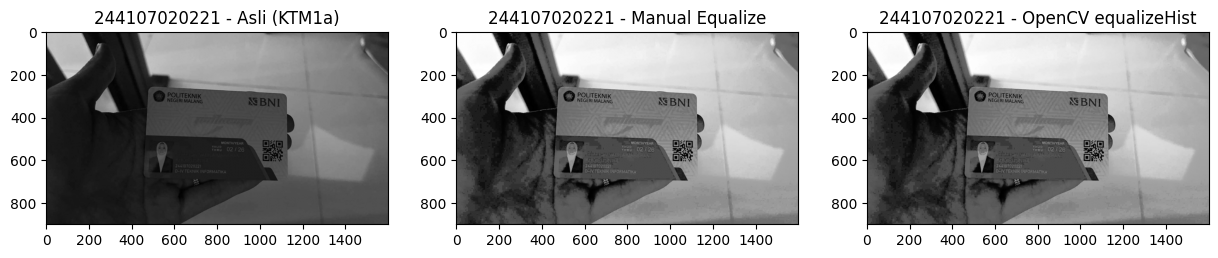

In [13]:
import os
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

NIM = '244107020221'  # <-- Ganti dengan NIM Anda
CONTOH = '/content/drive/MyDrive/PCVK 2026/Images'
BASE = '/content/drive/MyDrive/PCVK 2026/Images/' + NIM


# Fungsi Ekualisasi Histogram Manual
def manual_equalize(gray_img):
  h, _ = np.histogram(gray_img.ravel(), bins=256, range=[0, 256])
  p = h / gray_img.size
  cdf = np.cumsum(p)
  sk = np.round(cdf * 255).astype(np.uint8)
  return sk[gray_img]


# --- TAHAP 1: Citra Contoh (Lenna.png / lena_lc.jpg) ---
img_lc_path = os.path.join(CONTOH, 'Lenna.png')
gray_lc = cv.imread(img_lc_path, cv.IMREAD_GRAYSCALE)

if gray_lc is not None:
  eq_manual_lc = manual_equalize(gray_lc)
  eq_cv_lc = cv.equalizeHist(gray_lc)
  diff_lc = np.max(np.abs(eq_manual_lc.astype(int) - eq_cv_lc.astype(int)))

  print(
      f'[{NIM}] Selisih Maksimum Manual vs cv.equalizeHist (Lenna.png):'
      f' {diff_lc}'
  )

  # Visualisasi Tahap 1
  fig, axs = plt.subplots(1, 3, figsize=(15, 4))
  axs[0].imshow(gray_lc, cmap='gray')
  axs[0].set_title(f'{NIM} - Asli (Lenna)')
  axs[1].imshow(eq_manual_lc, cmap='gray')
  axs[1].set_title(f'{NIM} - Manual Equalize')
  axs[2].imshow(eq_cv_lc, cmap='gray')
  axs[2].set_title(f'{NIM} - OpenCV equalizeHist')
  plt.show()

# --- TAHAP 2: Citra Sendiri (KTM1a.jpg - Ruangan Gelap) ---
ktm_dark_path = os.path.join(BASE, 'KTM1a.jpg')
gray_ktm = cv.imread(ktm_dark_path, cv.IMREAD_GRAYSCALE)

if gray_ktm is not None:
  eq_manual_ktm = manual_equalize(gray_ktm)
  eq_cv_ktm = cv.equalizeHist(gray_ktm)
  diff_ktm = np.max(np.abs(eq_manual_ktm.astype(int) - eq_cv_ktm.astype(int)))

  print(
      f'[{NIM}] Selisih Maksimum Manual vs cv.equalizeHist (KTM1a.jpg):'
      f' {diff_ktm}'
  )

  # Visualisasi Tahap 2
  fig, axs = plt.subplots(1, 3, figsize=(15, 4))
  axs[0].imshow(gray_ktm, cmap='gray')
  axs[0].set_title(f'{NIM} - Asli (KTM1a)')
  axs[1].imshow(eq_manual_ktm, cmap='gray')
  axs[1].set_title(f'{NIM} - Manual Equalize')
  axs[2].imshow(eq_cv_ktm, cmap='gray')
  axs[2].set_title(f'{NIM} - OpenCV equalizeHist')
  plt.show()

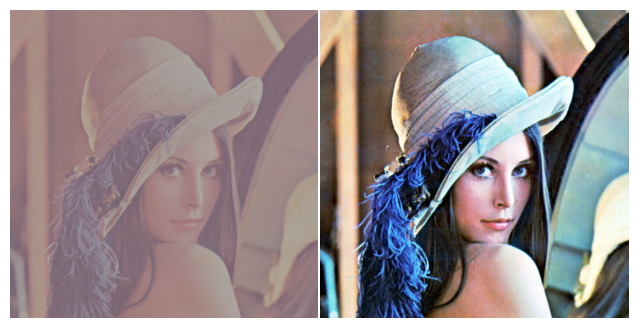

In [24]:
import os
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

# 1. Deklarasi NIM Anda
NIM = '244107020221'

# Path direktori contoh
CONTOH = '/content/drive/MyDrive/PCVK 2026/Images/244107020221'

# Path ke file Lenna yang ada di Drive
path_img = os.path.join(CONTOH, 'Lenna.png')
if not os.path.exists(path_img):
  path_img = os.path.join(CONTOH, 'lena.jpg')

# Read image
img_bgr = cv.imread(path_img)

if img_bgr is not None:
  # 1. Buat citra Low Contrast (pudar abu-abu seperti lena_lc.jpg di modul)
  # Menekan rentang kontras ke area tengah (misal 100 - 180)
  img_lc_bgr = (img_bgr.astype(np.float32) * 0.3 + 100).astype(np.uint8)

  # 2. Citra Kanan: Ekualisasi histogram pada kanal B, G, R terpisah dari citra low contrast
  b, g, r = cv.split(img_lc_bgr)
  b_eq = cv.equalizeHist(b)
  g_eq = cv.equalizeHist(g)
  r_eq = cv.equalizeHist(r)

  img_kanan_bgr = cv.merge([b_eq, g_eq, r_eq])

  # 3. Konversi BGR ke RGB untuk plot
  img_kiri_rgb = cv.cvtColor(img_lc_bgr, cv.COLOR_BGR2RGB)
  img_kanan_rgb = cv.cvtColor(img_kanan_bgr, cv.COLOR_BGR2RGB)

  # 4. Tampilkan berdampingan persis modul
  fig, axs = plt.subplots(1, 2, figsize=(8, 4))

  axs[0].imshow(img_kiri_rgb)
  axs[0].axis('off')

  axs[1].imshow(img_kanan_rgb)
  axs[1].axis('off')

  plt.subplots_adjust(wspace=0, hspace=0)
  plt.show()
else:
  print(f'Gagal membaca file dari: {path_img}')

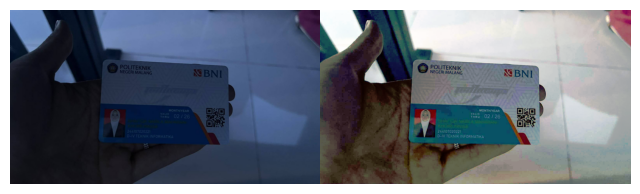

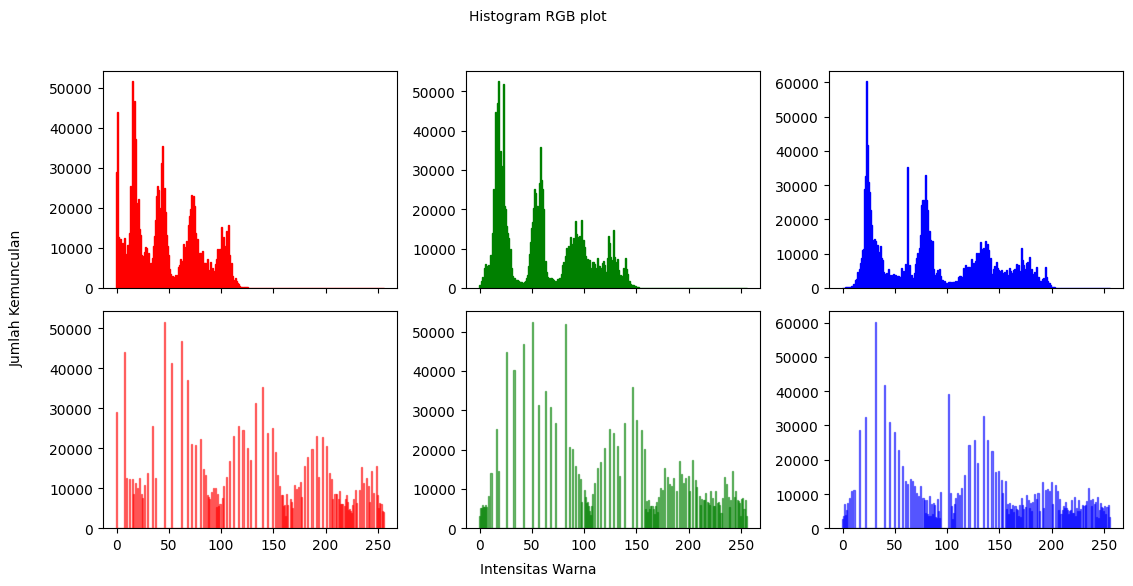

In [26]:
import os
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

# 1. Deklarasi NIM Anda
NIM = '244107020221'

# Path ke citra KTM1a.jpg milik Anda
BASE = '/content/drive/MyDrive/PCVK 2026/Images/' + NIM
path_ktm = os.path.join(BASE, 'KTM1a.jpg')

# 1. Baca citra KTM1a mode BGR (Berwarna)
img_ktm_bgr = cv.imread(path_ktm)

if img_ktm_bgr is not None:
  # 2. Ekualisasi Masing-masing Kanal B, G, R
  b, g, r = cv.split(img_ktm_bgr)
  b_eq = cv.equalizeHist(b)
  g_eq = cv.equalizeHist(g)
  r_eq = cv.equalizeHist(r)
  img_eq_bgr = cv.merge([b_eq, g_eq, r_eq])

  # 3. Tampilkan Citra Berdampingan (Sebelum & Sesudah Ekualisasi)
  img_ktm_rgb = cv.cvtColor(img_ktm_bgr, cv.COLOR_BGR2RGB)
  img_eq_rgb = cv.cvtColor(img_eq_bgr, cv.COLOR_BGR2RGB)

  fig, axs = plt.subplots(1, 2, figsize=(8, 4))
  axs[0].imshow(img_ktm_rgb)
  axs[0].axis('off')

  axs[1].imshow(img_eq_rgb)
  axs[1].axis('off')

  plt.subplots_adjust(wspace=0, hspace=0)
  plt.show()

  # 4. Hitung Histogram Kanal R, G, B Sebelum & Sesudah
  h_r_before, _ = np.histogram(r.ravel(), bins=256, range=[0, 256])
  h_g_before, _ = np.histogram(g.ravel(), bins=256, range=[0, 256])
  h_b_before, _ = np.histogram(b.ravel(), bins=256, range=[0, 256])

  h_r_after, _ = np.histogram(r_eq.ravel(), bins=256, range=[0, 256])
  h_g_after, _ = np.histogram(g_eq.ravel(), bins=256, range=[0, 256])
  h_b_after, _ = np.histogram(b_eq.ravel(), bins=256, range=[0, 256])

  # 5. Tampilkan Grafik Histogram 2 x 3 (Persis Gambar Jobsheet)
  fig, axs = plt.subplots(2, 3, figsize=(12, 6), sharex=True)
  fig.suptitle('Histogram RGB plot', fontsize=10)

  # Baris 1: Histogram Sebelum Ekualisasi (KTM1a Asli)
  axs[0, 0].bar(
      range(256), h_r_before, color='red', width=1.0, edgecolor='red'
  )
  axs[0, 1].bar(
      range(256), h_g_before, color='green', width=1.0, edgecolor='green'
  )
  axs[0, 2].bar(
      range(256), h_b_before, color='blue', width=1.0, edgecolor='blue'
  )

  # Baris 2: Histogram Sesudah Ekualisasi
  axs[1, 0].bar(
      range(256),
      h_r_after,
      color='red',
      width=1.0,
      edgecolor='red',
      alpha=0.5,
  )
  axs[1, 1].bar(
      range(256),
      h_g_after,
      color='green',
      width=1.0,
      edgecolor='green',
      alpha=0.5,
  )
  axs[1, 2].bar(
      range(256),
      h_b_after,
      color='blue',
      width=1.0,
      edgecolor='blue',
      alpha=0.5,
  )

  # Labeling Sumbu
  fig.text(0.06, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
  fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')

  plt.tight_layout(rect=[0.08, 0.05, 1, 0.95])
  plt.show()
else:
  print(f'Gagal membaca file dari path: {path_ktm}')

In [27]:
import os
import cv2 as cv
import numpy as np

# 1. Deklarasi NIM Anda
NIM = '244107020221'

# Path direktori
CONTOH = '/content/drive/MyDrive/PCVK 2026/Images'
BASE = '/content/drive/MyDrive/PCVK 2026/Images/' + NIM


# Fungsi Ekualisasi Histogram Manual per-kanal
def manual_equalize(channel):
  h, _ = np.histogram(channel.ravel(), bins=256, range=[0, 256])
  p = h / channel.size
  cdf = np.cumsum(p)
  sk = np.round(cdf * 255).astype(np.uint8)
  return sk[channel]


def uji_dan_bandingkan(path_gambar, nama_label):
  image = cv.imread(path_gambar)

  if image is None:
    print(f'[{NIM}] Gagal membaca gambar pada: {path_gambar}')
    return

  # A. Menggunakan cv2.equalizeHist (sesuai potongan kode di jobsheet)
  b, g, r = cv.split(image)
  b_equalized = cv.equalizeHist(b)
  g_equalized = cv.equalizeHist(g)
  r_equalized = cv.equalizeHist(r)
  img_cv = cv.merge([b_equalized, g_equalized, r_equalized])

  # B. Menggunakan implementasi Manual
  b_manual = manual_equalize(b)
  g_manual = manual_equalize(g)
  r_manual = manual_equalize(r)
  img_manual = cv.merge([b_manual, g_manual, r_manual])

  # C. Menghitung Selisih Maksimum per Kanal
  diff_b = np.max(np.abs(b_equalized.astype(int) - b_manual.astype(int)))
  diff_g = np.max(np.abs(g_equalized.astype(int) - g_manual.astype(int)))
  diff_r = np.max(np.abs(r_equalized.astype(int) - r_manual.astype(int)))
  max_diff_total = max(diff_b, diff_g, diff_r)

  # Tampilkan Hasil
  print(f'=== Hasil Perbandingan untuk {nama_label} [{NIM}] ===')
  print(f'Selisih Maksimum Kanal B : {diff_b}')
  print(f'Selisih Maksimum Kanal G : {diff_g}')
  print(f'Selisih Maksimum Kanal R : {diff_r}')
  print(f'Selisih Maksimum Total   : {max_diff_total}')
  print('-' * 55)


# 1. Pengujian pada citra contoh (Lenna.png / lena_lc.jpg)
path_lenna = os.path.join(CONTOH, 'Lenna.png')
if not os.path.exists(path_lenna):
  path_lenna = os.path.join(CONTOH, 'lena_lc.jpg')
uji_dan_bandingkan(path_lenna, 'Lenna.png')

# 2. Pengujian pada citra pribadi (KTM1a.jpg)
path_ktm = os.path.join(BASE, 'KTM1a.jpg')
uji_dan_bandingkan(path_ktm, 'KTM1a.jpg')

[244107020221] Gagal membaca gambar pada: /content/drive/MyDrive/PCVK 2026/Images/lena_lc.jpg
=== Hasil Perbandingan untuk KTM1a.jpg [244107020221] ===
Selisih Maksimum Kanal B : 0
Selisih Maksimum Kanal G : 1
Selisih Maksimum Kanal R : 5
Selisih Maksimum Total   : 5
-------------------------------------------------------


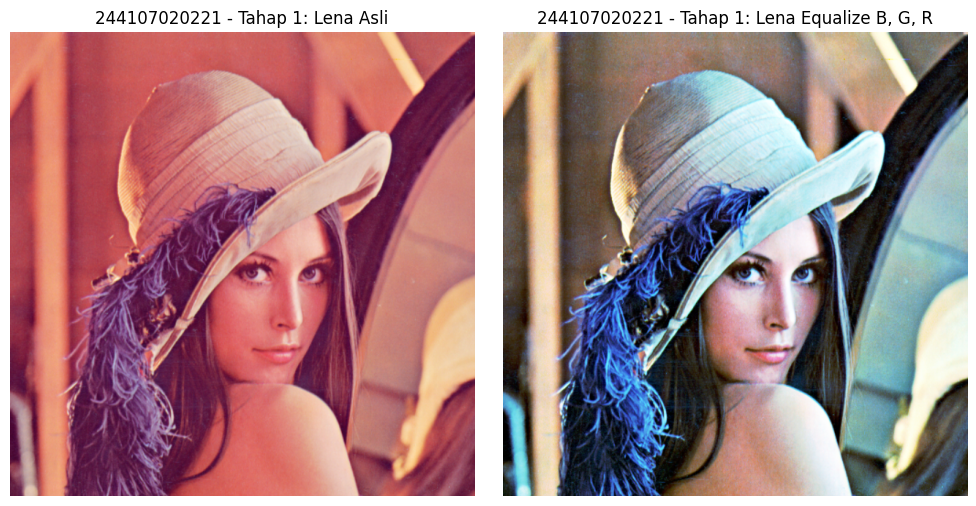

In [30]:
import os
import cv2 as cv
import matplotlib.pyplot as plt

# 1. Deklarasi NIM Anda
NIM = '244107020221'

# Path direktori contoh
CONTOH = '/content/drive/MyDrive/PCVK 2026/Images/244107020221'

# Path ke file contoh lena
path_lena = os.path.join(CONTOH, 'lena.jpg')
if not os.path.exists(path_lena):
  path_lena = os.path.join(CONTOH, 'Lenna.png')

# Baca citra BGR (Berwarna)
bgr_lena = cv.imread(path_lena)

if bgr_lena is not None:
  # Cara 1: Tiap kanal B, G, R diekualisasi sendiri-sendiri
  kanal = list(cv.split(bgr_lena))
  for i in range(3):
    kanal[i] = cv.equalizeHist(kanal[i])
  he_rgb_lena = cv.merge(kanal)

  # Konversi BGR ke RGB untuk tampilan Matplotlib
  lena_asli_rgb = cv.cvtColor(bgr_lena, cv.COLOR_BGR2RGB)
  lena_eq_rgb = cv.cvtColor(he_rgb_lena, cv.COLOR_BGR2RGB)

  # Plot Berdampingan
  fig, axs = plt.subplots(1, 2, figsize=(10, 5))

  axs[0].imshow(lena_asli_rgb)
  axs[0].set_title(f'{NIM} - Tahap 1: Lena Asli')
  axs[0].axis('off')

  axs[1].imshow(lena_eq_rgb)
  axs[1].set_title(f'{NIM} - Tahap 1: Lena Equalize B, G, R')
  axs[1].axis('off')

  plt.tight_layout()
  plt.show()
else:
  print(f'Gagal membaca file dari path: {path_lena}')

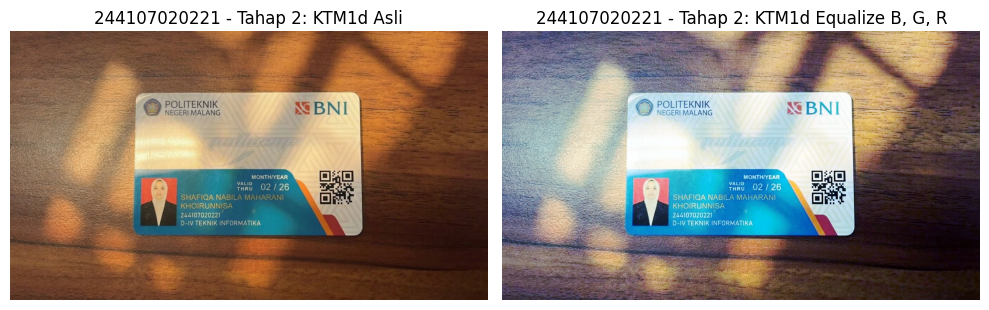

In [31]:
import os
import cv2 as cv
import matplotlib.pyplot as plt

# 1. Deklarasi NIM Anda
NIM = '244107020221'

# Path ke file KTM1d.jpg milik Anda
BASE = '/content/drive/MyDrive/PCVK 2026/Images/' + NIM
path_ktm = os.path.join(BASE, 'KTM1d.jpg')

# Baca citra BGR (Berwarna)
bgr_ktm = cv.imread(path_ktm)

if bgr_ktm is not None:
  # Cara 1: Tiap kanal B, G, R diekualisasi sendiri-sendiri
  kanal = list(cv.split(bgr_ktm))
  for i in range(3):
    kanal[i] = cv.equalizeHist(kanal[i])
  he_rgb_ktm = cv.merge(kanal)

  # Konversi BGR ke RGB untuk tampilan Matplotlib
  ktm_asli_rgb = cv.cvtColor(bgr_ktm, cv.COLOR_BGR2RGB)
  ktm_eq_rgb = cv.cvtColor(he_rgb_ktm, cv.COLOR_BGR2RGB)

  # Plot Berdampingan
  fig, axs = plt.subplots(1, 2, figsize=(10, 5))

  axs[0].imshow(ktm_asli_rgb)
  axs[0].set_title(f'{NIM} - Tahap 2: KTM1d Asli')
  axs[0].axis('off')

  axs[1].imshow(ktm_eq_rgb)
  axs[1].set_title(f'{NIM} - Tahap 2: KTM1d Equalize B, G, R')
  axs[1].axis('off')

  plt.tight_layout()
  plt.show()
else:
  print(f'Gagal membaca file dari path: {path_ktm}')

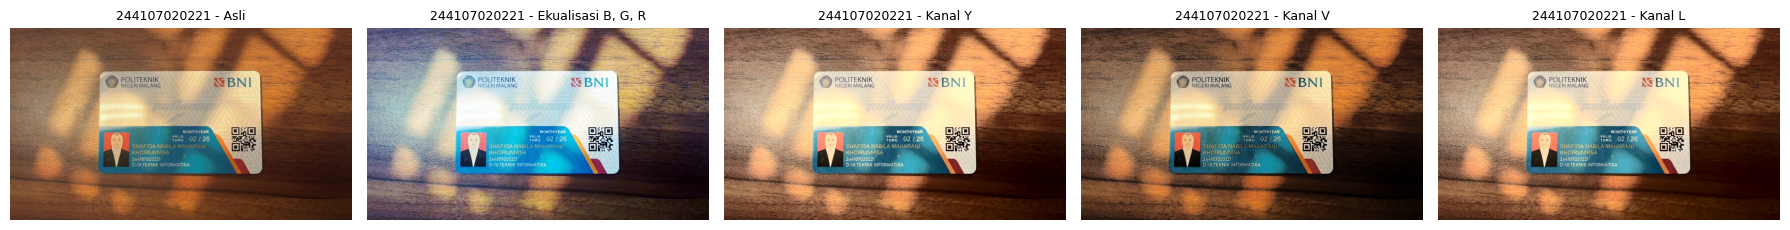

Cara                    geser Hue (der)    rerata terang
----------------------------------------------------------
Asli                               0.00            105.1
Ekualisasi B, G, R                58.77            128.2
Kanal Y                            1.51            127.8
Kanal V                            0.54             99.2
Kanal L                            2.04            122.0


In [32]:
import os
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

# 1. Deklarasi NIM Anda
NIM = '244107020221'

# Path berkas KTM1d.jpg
BASE = '/content/drive/MyDrive/PCVK 2026/Images/' + NIM
berkas = os.path.join(BASE, 'KTM1d.jpg')

# Baca citra BGR
bgr = cv.imread(berkas)

if bgr is not None:
  # Cara 1: Tiap kanal diekualisasi sendiri-sendiri
  kanal = list(cv.split(bgr))
  for i in range(3):
    kanal[i] = cv.equalizeHist(kanal[i])
  he_rgb = cv.merge(kanal)

  # Cara 2: Hanya kanal terang yang diekualisasi (YCrCb)
  ycrcb = cv.cvtColor(bgr, cv.COLOR_BGR2YCrCb)
  y, cr, cb = cv.split(ycrcb)
  he_y = cv.cvtColor(
      cv.merge([cv.equalizeHist(y), cr, cb]), cv.COLOR_YCrCb2BGR
  )

  # Varian setara pada HSV (Kanal V)
  hsv = cv.cvtColor(bgr, cv.COLOR_BGR2HSV)
  h, sat, v = cv.split(hsv)
  he_v = cv.cvtColor(cv.merge([h, sat, cv.equalizeHist(v)]), cv.COLOR_HSV2BGR)

  # Varian setara pada LAB (Kanal L)
  lab = cv.cvtColor(bgr, cv.COLOR_BGR2LAB)
  l, a, b = cv.split(lab)
  he_l = cv.cvtColor(cv.merge([cv.equalizeHist(l), a, b]), cv.COLOR_LAB2BGR)

  # 2. Tampilkan Kelimanya Berdampingan
  judul = ['Asli', 'Ekualisasi B, G, R', 'Kanal Y', 'Kanal V', 'Kanal L']
  citra = [bgr, he_rgb, he_y, he_v, he_l]

  plt.figure(figsize=(18, 4))
  for i, (c, t) in enumerate(zip(citra, judul), 1):
    plt.subplot(1, 5, i)
    plt.imshow(cv.cvtColor(c, cv.COLOR_BGR2RGB))
    plt.title(NIM + ' - ' + t, fontsize=9)
    plt.axis('off')
  plt.tight_layout()
  plt.show()


  # 3. Fungsi Menghitung Pergeseran Hue Melingkar (0-179)
  def geser_hue(asli, hasil):
    h1 = cv.cvtColor(asli, cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
    h2 = cv.cvtColor(hasil, cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
    d = np.abs(h1 - h2)
    d = np.minimum(d, 180 - d)  # Hue melingkar 0-179
    return d.mean()


  # 4. Cetak Tabel Perbandingan Pengukuran
  print('%-22s %16s %16s' % ('Cara', 'geser Hue (der)', 'rerata terang'))
  print('-' * 58)
  for t, c in zip(judul, citra):
    print(
        '%-22s %16.2f %16.1f'
        % (
            t,
            geser_hue(bgr, c) * 2,
            cv.cvtColor(c, cv.COLOR_BGR2GRAY).mean(),
        )
    )
else:
  print(f'Gagal membaca file dari path: {berkas}')

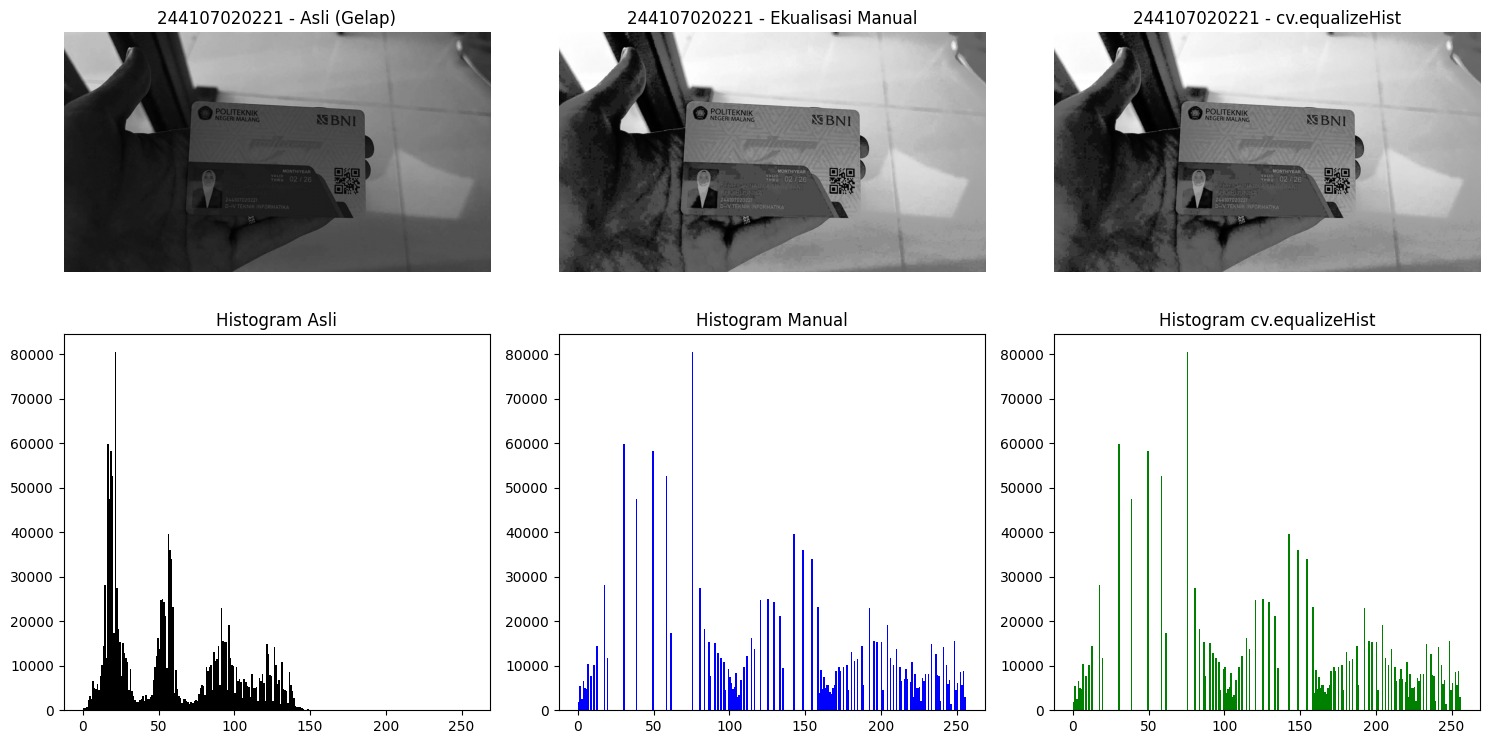

In [1]:
import os
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

NIM = '244107020221'
BASE = '/content/drive/MyDrive/PCVK 2026/Images/' + NIM
path_ktm = os.path.join(BASE, 'KTM1a.jpg')

# Baca citra grayscale
img_asli = cv.imread(path_ktm, cv.IMREAD_GRAYSCALE)


# Ekualisasi Manual
def manual_equalize(gray_img):
  h, _ = np.histogram(gray_img.ravel(), bins=256, range=[0, 256])
  cdf = (h / gray_img.size).cumsum()
  sk = np.round(cdf * 255).astype(np.uint8)
  return sk[gray_img]


img_manual = manual_equalize(img_asli)
img_cv = cv.equalizeHist(img_asli)

# Tampilkan Layout (Citra Asli, Ekualisasi, dan Histogram)
fig, axs = plt.subplots(2, 3, figsize=(15, 8))

# Baris 1: Citra
axs[0, 0].imshow(img_asli, cmap='gray')
axs[0, 0].set_title(f'{NIM} - Asli (Gelap)')
axs[0, 0].axis('off')

axs[0, 1].imshow(img_manual, cmap='gray')
axs[0, 1].set_title(f'{NIM} - Ekualisasi Manual')
axs[0, 1].axis('off')

axs[0, 2].imshow(img_cv, cmap='gray')
axs[0, 2].set_title(f'{NIM} - cv.equalizeHist')
axs[0, 2].axis('off')

# Baris 2: Histogram
axs[1, 0].hist(img_asli.ravel(), bins=256, range=[0, 256], color='black')
axs[1, 0].set_title('Histogram Asli')

axs[1, 1].hist(img_manual.ravel(), bins=256, range=[0, 256], color='blue')
axs[1, 1].set_title('Histogram Manual')

axs[1, 2].hist(img_cv.ravel(), bins=256, range=[0, 256], color='green')
axs[1, 2].set_title('Histogram cv.equalizeHist')

plt.tight_layout()
plt.show()

In [2]:
psnr_val = cv.PSNR(img_asli, img_cv)
print(f'Nilai PSNR Citra Asli vs Hasil Ekualisasi: {psnr_val:.2f} dB')

Nilai PSNR Citra Asli vs Hasil Ekualisasi: 10.06 dB


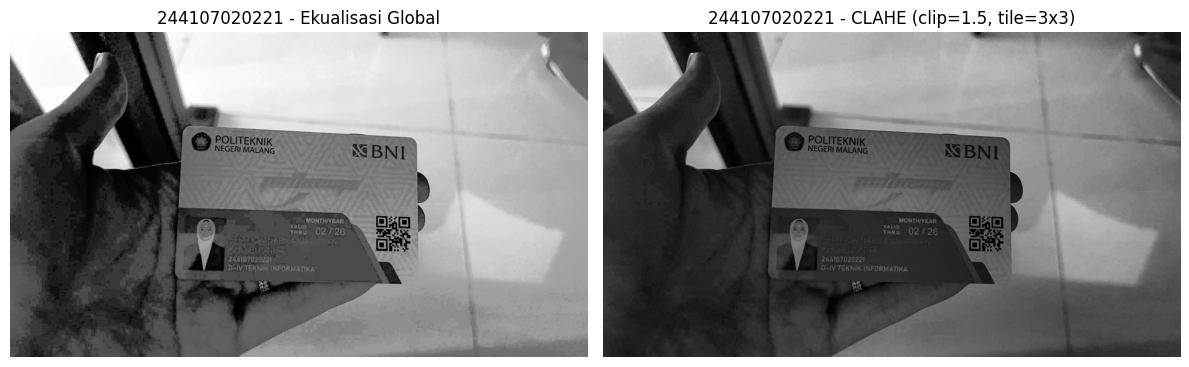

In [3]:
# Parameter berdasarkan NIM 244107020221
CLIP_LIMIT = 1.5
TILE_SIZE = (3, 3)

# CLAHE
clahe = cv.createCLAHE(clipLimit=CLIP_LIMIT, tileGridSize=TILE_SIZE)
img_clahe = clahe.apply(img_asli)

# Visualisasi Perbandingan
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
axs[0].imshow(img_cv, cmap='gray')
axs[0].set_title(f'{NIM} - Ekualisasi Global')
axs[0].axis('off')

axs[1].imshow(img_clahe, cmap='gray')
axs[1].set_title(
    f'{NIM} - CLAHE (clip={CLIP_LIMIT}, tile={TILE_SIZE[0]}x{TILE_SIZE[1]})'
)
axs[1].axis('off')

plt.tight_layout()
plt.show()

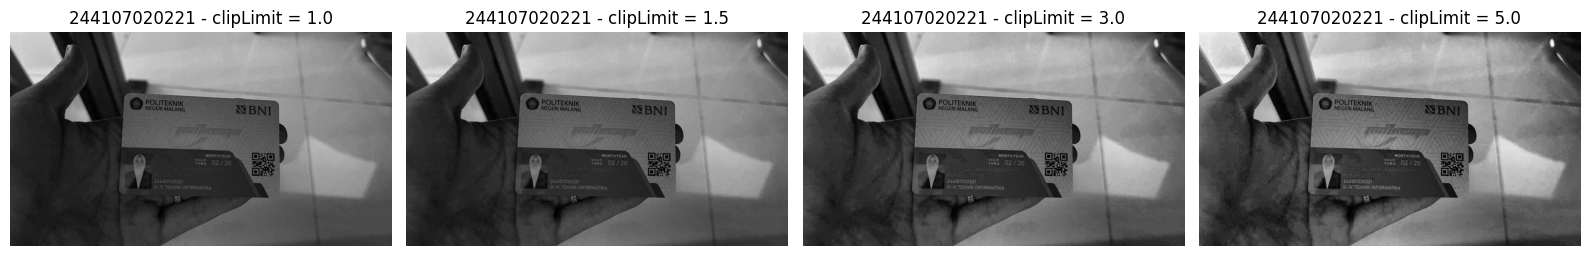

In [4]:
# Tiga nilai clipLimit di sekitar 1.5
clips = [1.0, 1.5, 3.0, 5.0]

plt.figure(figsize=(16, 4))
for i, clip in enumerate(clips, 1):
  c_obj = cv.createCLAHE(clipLimit=clip, tileGridSize=TILE_SIZE)
  res = c_obj.apply(img_asli)

  plt.subplot(1, 4, i)
  plt.imshow(res, cmap='gray')
  plt.title(f'{NIM} - clipLimit = {clip}')
  plt.axis('off')

plt.tight_layout()
plt.show()

In [7]:
import os
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

NIM = '244107020221'
CONTOH = '/content/drive/MyDrive/PCVK 2026/Images/244107020221'
BASE = '/content/drive/MyDrive/PCVK 2026/Images/' + NIM


def floyd_steinberg_dithering(img, levels=2):
  """Melakukan Floyd-Steinberg Dithering pada tiap kanal warna."""
  # Ubah ke float32 agar komputasi eror tidak overflow/underflow
  img_float = img.astype(np.float32)
  h, w, c = img_float.shape

  step = 255.0 / (levels - 1)

  for y in range(h):
    for x in range(w):
      for k in range(c):
        old_val = img_float[y, x, k]
        # Kuantisasi ke level terdekat
        new_val = np.round(old_val / step) * step
        img_float[y, x, k] = new_val

        # Hitung Error
        err = old_val - new_val

        # Distribusi Error Floyd-Steinberg
        if x + 1 < w:
          img_float[y, x + 1, k] += err * 7 / 16
        if y + 1 < h:
          if x - 1 >= 0:
            img_float[y + 1, x - 1, k] += err * 3 / 16
          img_float[y + 1, x, k] += err * 5 / 16
          if x + 1 < w:
            img_float[y + 1, x + 1, k] += err * 1 / 16

  return np.clip(img_float, 0, 255).astype(np.uint8)

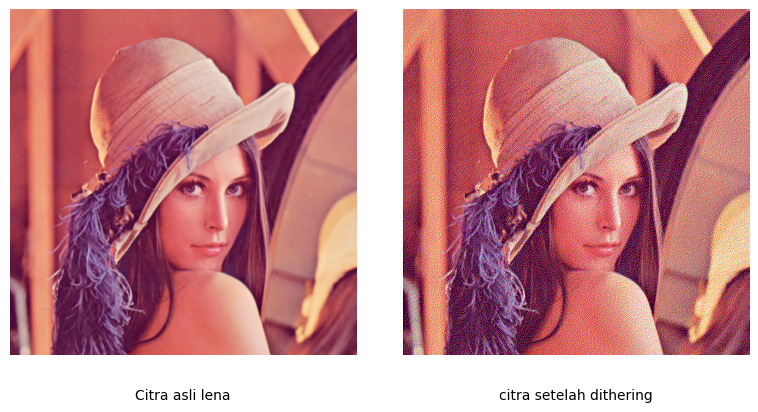

In [8]:
path_lena = os.path.join(CONTOH, 'lena.jpg')
if not os.path.exists(path_lena):
  path_lena = os.path.join(CONTOH, 'Lenna.png')

img_lena_bgr = cv.imread(path_lena)

if img_lena_bgr is not None:
  # Lakukan Dithering
  img_dither_lena = floyd_steinberg_dithering(img_lena_bgr, levels=2)

  # Plot Berdampingan Persis Modul
  fig, axs = plt.subplots(1, 2, figsize=(8, 4))

  axs[0].imshow(cv.cvtColor(img_lena_bgr, cv.COLOR_BGR2RGB))
  axs[0].set_title('Citra asli lena', fontsize=10, y=-0.15)
  axs[0].axis('off')

  axs[1].imshow(cv.cvtColor(img_dither_lena, cv.COLOR_BGR2RGB))
  axs[1].set_title('citra setelah dithering', fontsize=10, y=-0.15)
  axs[1].axis('off')

  plt.tight_layout()
  plt.show()
else:
  print(f'Gagal membaca file dari path: {path_lena}')

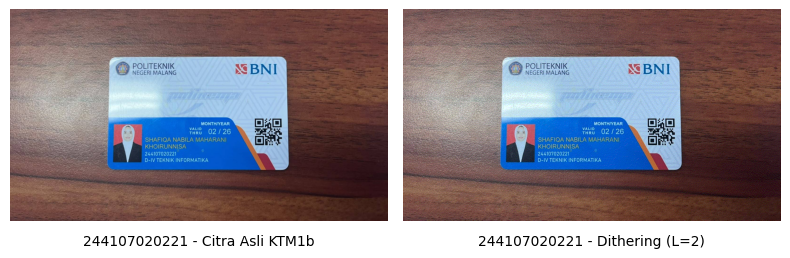

In [9]:
path_ktm = os.path.join(BASE, 'KTM1b.jpg')
img_ktm_bgr = cv.imread(path_ktm)

# Level L = 2 berdasarkan NIM 244107020221
LEVEL_L = 2

if img_ktm_bgr is not None:
  # Lakukan Dithering pada KTM1b
  img_dither_ktm = floyd_steinberg_dithering(img_ktm_bgr, levels=LEVEL_L)

  # Plot Berdampingan
  fig, axs = plt.subplots(1, 2, figsize=(8, 4))

  axs[0].imshow(cv.cvtColor(img_ktm_bgr, cv.COLOR_BGR2RGB))
  axs[0].set_title(f'{NIM} - Citra Asli KTM1b', fontsize=10, y=-0.15)
  axs[0].axis('off')

  axs[1].imshow(cv.cvtColor(img_dither_ktm, cv.COLOR_BGR2RGB))
  axs[1].set_title(
      f'{NIM} - Dithering (L={LEVEL_L})', fontsize=10, y=-0.15
  )
  axs[1].axis('off')

  plt.tight_layout()
  plt.show()
else:
  print(f'Gagal membaca file dari path: {path_ktm}')

In [10]:
import os
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

# Deklarasi NIM Anda
NIM = '244107020221'
BASE = '/content/drive/MyDrive/PCVK 2026/Images/' + NIM
CONTOH = '/content/drive/MyDrive/PCVK 2026/Images'


def floyd_steinberg_gray(img_gray, levels=2):
  """Melakukan Floyd-Steinberg Dithering pada citra grayscale (2D)."""
  img_float = img_gray.copy().astype(np.float32)
  h, w = img_float.shape
  step = 255.0 / (levels - 1)

  for y in range(h):
    for x in range(w):
      old_val = img_float[y, x]
      new_val = np.round(old_val / step) * step
      img_float[y, x] = new_val
      err = old_val - new_val

      if x + 1 < w:
        img_float[y, x + 1] += err * 7 / 16
      if y + 1 < h:
        if x - 1 >= 0:
          img_float[y + 1, x - 1] += err * 3 / 16
        img_float[y + 1, x] += err * 5 / 16
        if x + 1 < w:
          img_float[y + 1, x + 1] += err * 1 / 16

  return np.clip(img_float, 0, 255).astype(np.uint8)

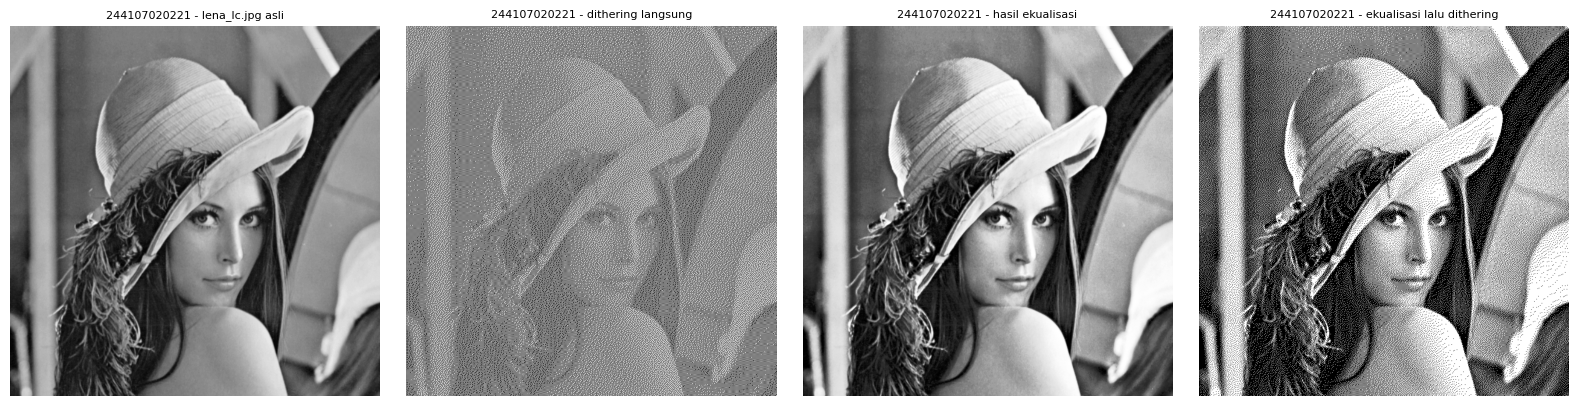

In [11]:
# Cek lokasi file Lena
path_lena = os.path.join(CONTOH, 'lena_lc.jpg')
if not os.path.exists(path_lena):
  path_lena = os.path.join(BASE, 'Lenna.png')

img_bgr = cv.imread(path_lena)

if img_bgr is not None:
  # Konversi ke Grayscale
  gray_asli = cv.cvtColor(img_bgr, cv.COLOR_BGR2GRAY)

  # Buat versi Low Contrast pudar jika menggunakan Lenna biasa
  if 'Lenna.png' in path_lena or 'lena.jpg' in path_lena:
    gray_lc = (gray_asli.astype(np.float32) * 0.3 + 100).astype(np.uint8)
  else:
    gray_lc = gray_asli

  # Proses 1: Dithering Langsung
  dither_langsung = floyd_steinberg_gray(gray_lc, levels=2)

  # Proses 2: Ekualisasi dulu
  gray_eq = cv.equalizeHist(gray_lc)

  # Proses 3: Dithering setelah Ekualisasi
  dither_eq = floyd_steinberg_gray(gray_eq, levels=2)

  # Plot 1x4 Sesuai Gambar Modul
  fig, axs = plt.subplots(1, 4, figsize=(16, 4))

  axs[0].imshow(gray_lc, cmap='gray')
  axs[0].set_title(f'{NIM} - lena_lc.jpg asli', fontsize=8)
  axs[0].axis('off')

  axs[1].imshow(dither_langsung, cmap='gray')
  axs[1].set_title(f'{NIM} - dithering langsung', fontsize=8)
  axs[1].axis('off')

  axs[2].imshow(gray_eq, cmap='gray')
  axs[2].set_title(f'{NIM} - hasil ekualisasi', fontsize=8)
  axs[2].axis('off')

  axs[3].imshow(dither_eq, cmap='gray')
  axs[3].set_title(f'{NIM} - ekualisasi lalu dithering', fontsize=8)
  axs[3].axis('off')

  plt.tight_layout()
  plt.show()